In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# train_base

以 forecast notebook 的 canonical 3-agent 配置为准。True 时重训当前 MADRL 方案；False 时严格读取当前 canonical 训练结果，并把测试 rollout 写入 `notebooks/record/madrl/`。

In [2]:

import json
import matplotlib.pyplot as plt

from pprint import pprint

import pandas as pd
from IPython.display import display

from configs.experiment_config import MADRL_NOTEBOOK_SPECS
from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.mainline_compare import collect_madrl_rollout, compare_rollout_metrics
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings, bootstrap_madrl_notebook_shared_data, plot_battery_power_and_soc_comparison, plot_net_load_comparison, plot_power_balance_comparison, plot_price_prediction_comparison, plot_voltage_profile_comparison, resolve_madrl_notebook_training, save_rollout_record
from scripts.utils.torch_runtime import configure_torch_runtime


In [3]:

# 唯一 notebook 参数：True 时重训当前 MADRL 方案；False 时严格读取现有 canonical run。
force_retrain_madrl = True


In [4]:

NOTEBOOK_KEY = 'train_base'
spec = MADRL_NOTEBOOK_SPECS[NOTEBOOK_KEY]
root = project_root()
cfg = compose_experiment_config(
    profile='base',
    algorithm=spec['algorithm'],
    forecast_type='lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode='normal',
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls['future_horizon']),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
cfg.algo.name = str(spec['algorithm'])
cfg.train.num_envs = int(spec['num_envs'])
cfg.train.vec_env_type = 'subproc' if cfg.train.num_envs > 1 else 'dummy'
cfg.forecast.auto_train_missing = False
for field_name, value in dict(spec.get('reward', {})).items():
    setattr(cfg.reward, field_name, float(value))
cfg.safety.enabled = bool(dict(spec.get('safety', {})).get('enabled', False))
# 训练严格依赖 notebooks/record/forecast/lstm/shared_data_record.json 产出的 shared-data 合同。
shared_data_contract = bootstrap_madrl_notebook_shared_data(
    cfg,
    root=root,
    notebook_path='notebooks/madrl/train_base.ipynb',
)
shared_data_signature = str(shared_data_contract['shared_data_signature'])
runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

config_snapshot = {
    'scheme_name': str(spec['scheme_name']),
    'display_label': str(spec['display_label']),
    'algorithm': str(spec['algorithm']),
    'experiment_name': str(spec['experiment_name']),
    'force_retrain_madrl': bool(force_retrain_madrl),
    'shared_data_signature': shared_data_signature,
    'cfg_summary': summarize_experiment(cfg),
}
display(pd.DataFrame([{
    'scheme_name': spec['scheme_name'],
    'algorithm': spec['algorithm'],
    'num_envs': cfg.train.num_envs,
    'test_start_date': cfg.data.test_start_date,
    'test_end_date': cfg.data.test_end_date,
    'shared_data_signature': shared_data_signature,
}]))


,scheme_name,algorithm,num_envs,test_start_date,test_end_date,shared_data_signature
0,madrl_base,MATD3,4,2020-04-01,2020-04-15,22a77ba3c2ee3138


Training:   0%|          | 0/201600 [00:00<?, ?step/s]


Training:   1%|1         | 2688/201600 [00:25<30:58, 107.05step/s]


Training:   1%|1         | 2688/201600 [00:40<30:58, 107.05step/s]


Training:   3%|2         | 5376/201600 [00:53<32:45, 99.83step/s] 


Training:   3%|2         | 5376/201600 [01:10<32:45, 99.83step/s]


...

'shared_data_signature'

: 

'22a77ba3c2ee3138'

}

1. 电力电量平衡

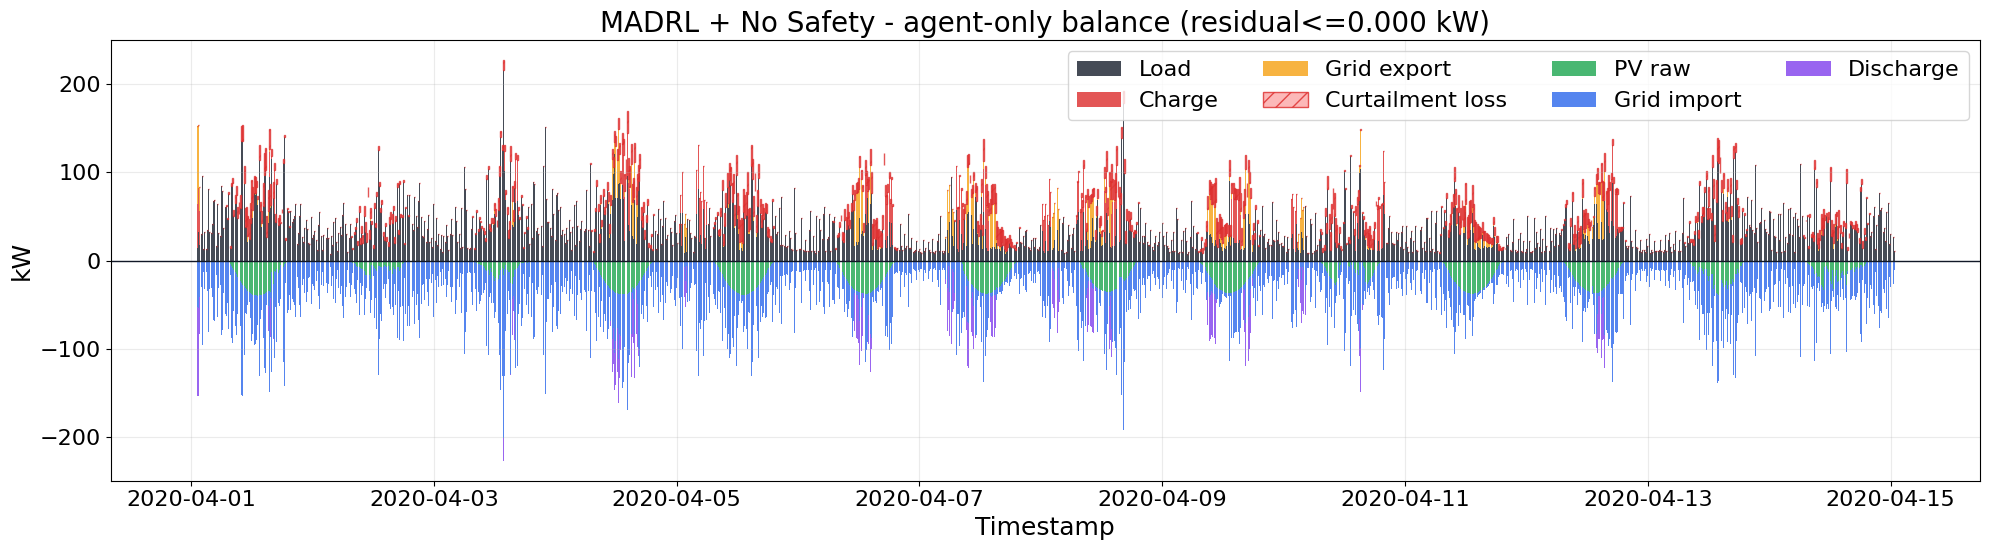

2. 电价

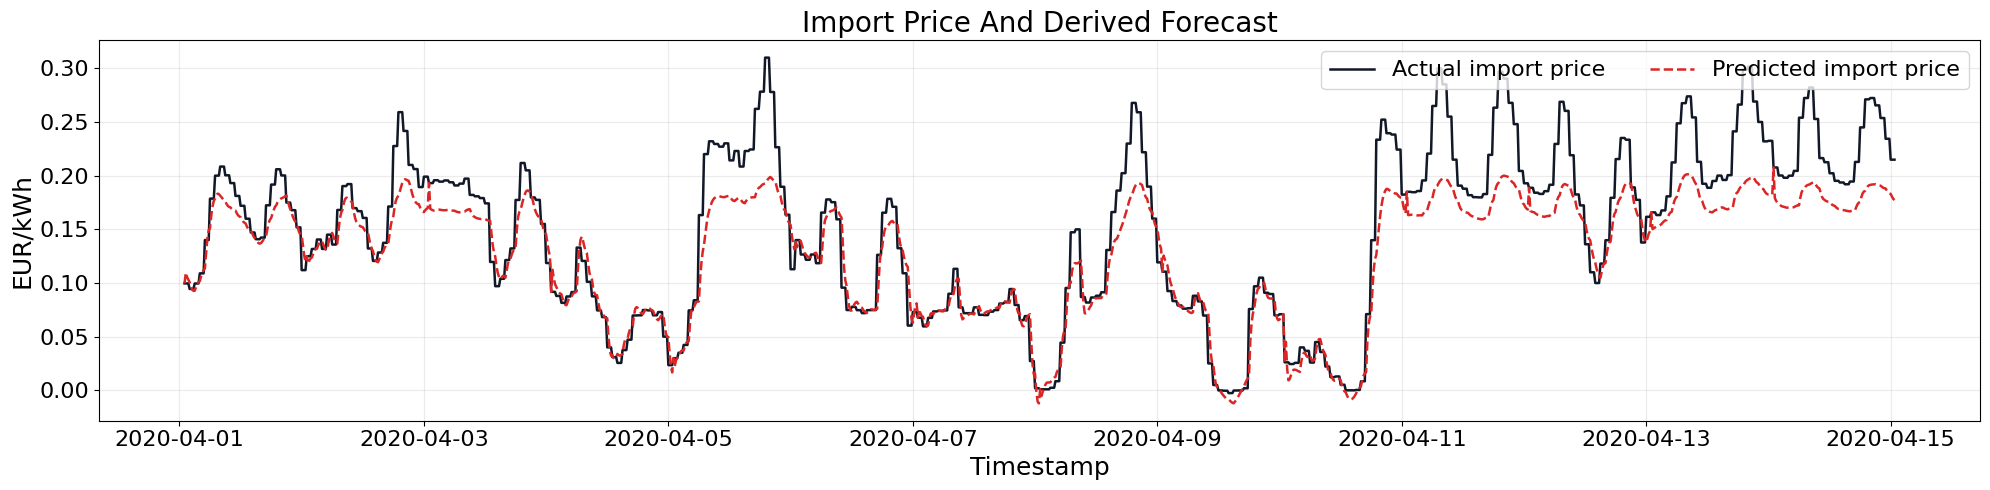

3. 总体储能充放功率与 SoC

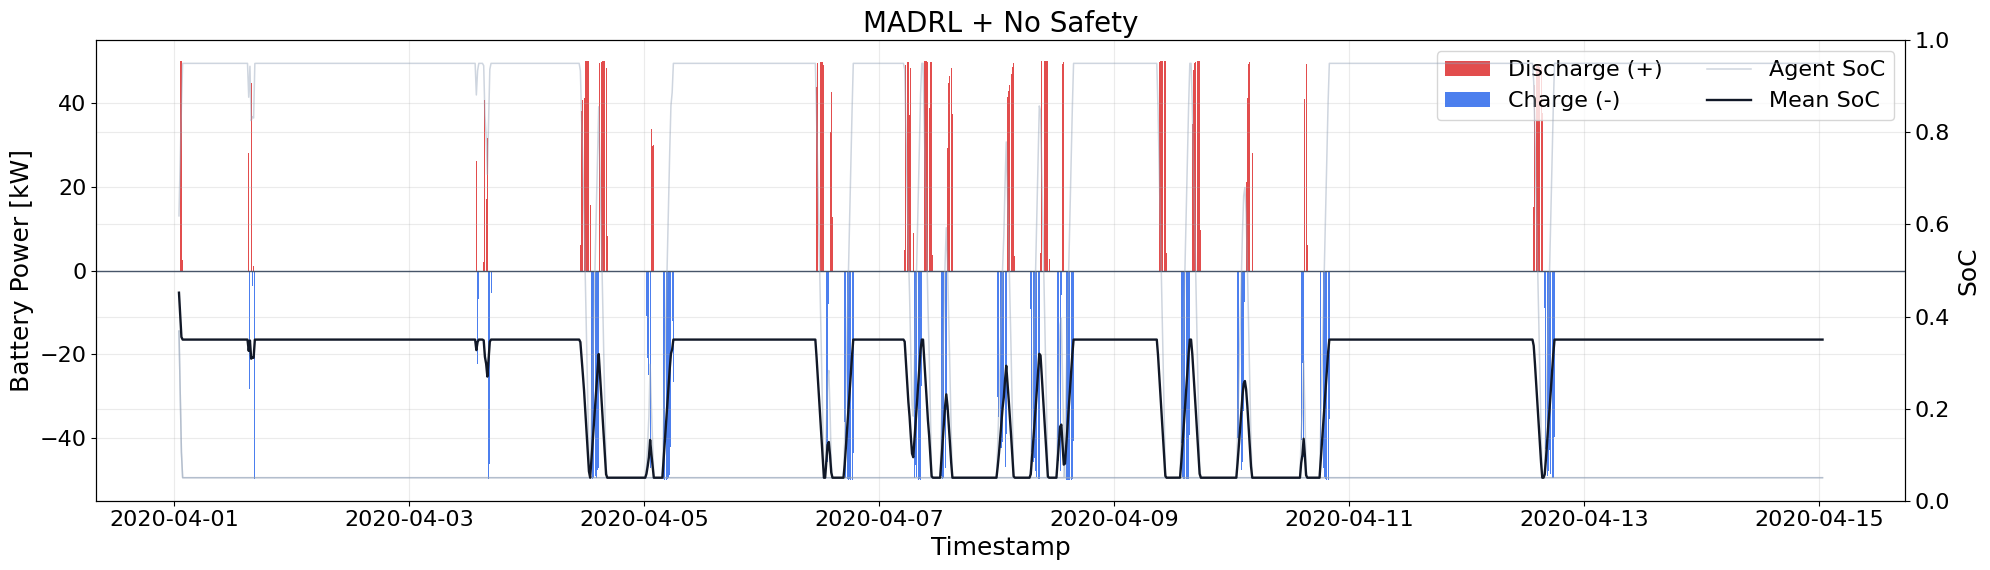

4. 电压

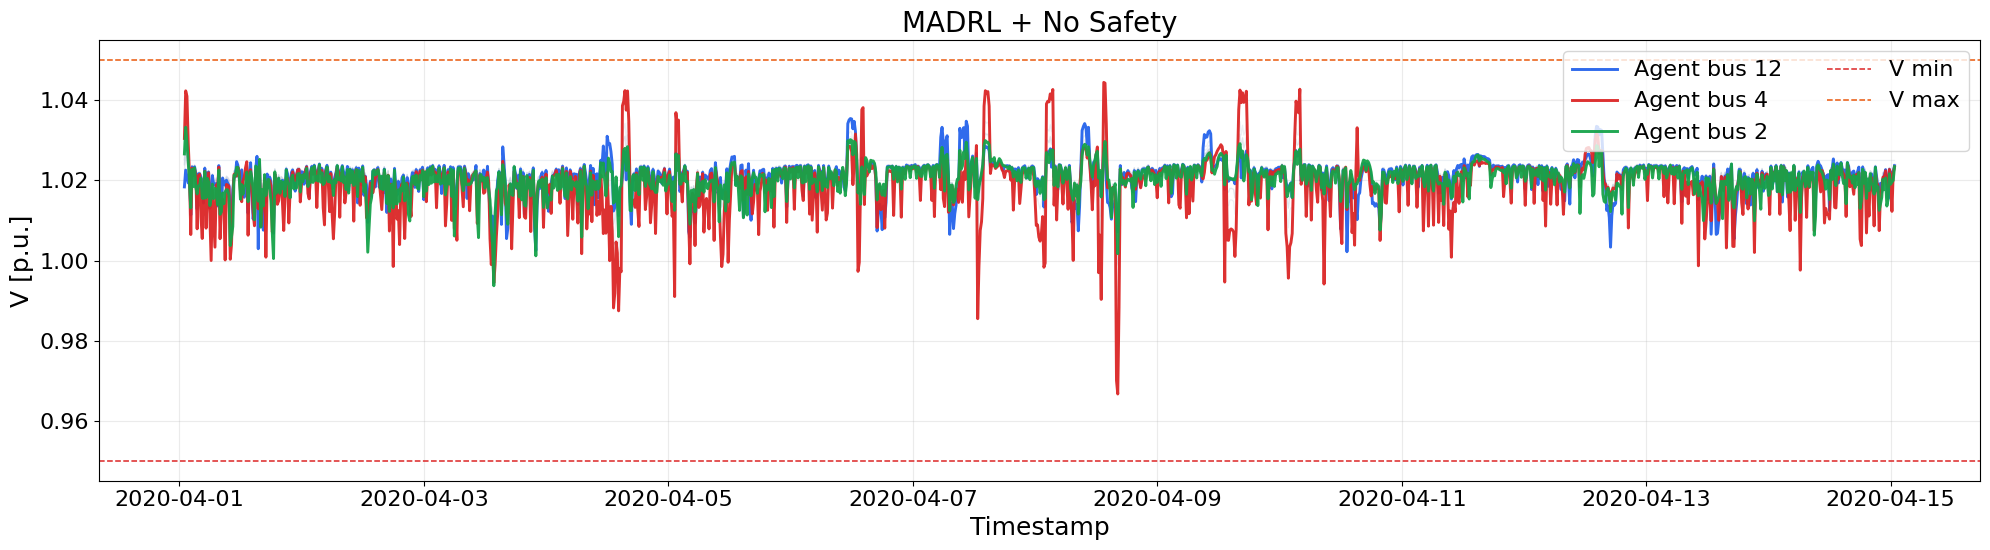

5. 净负荷

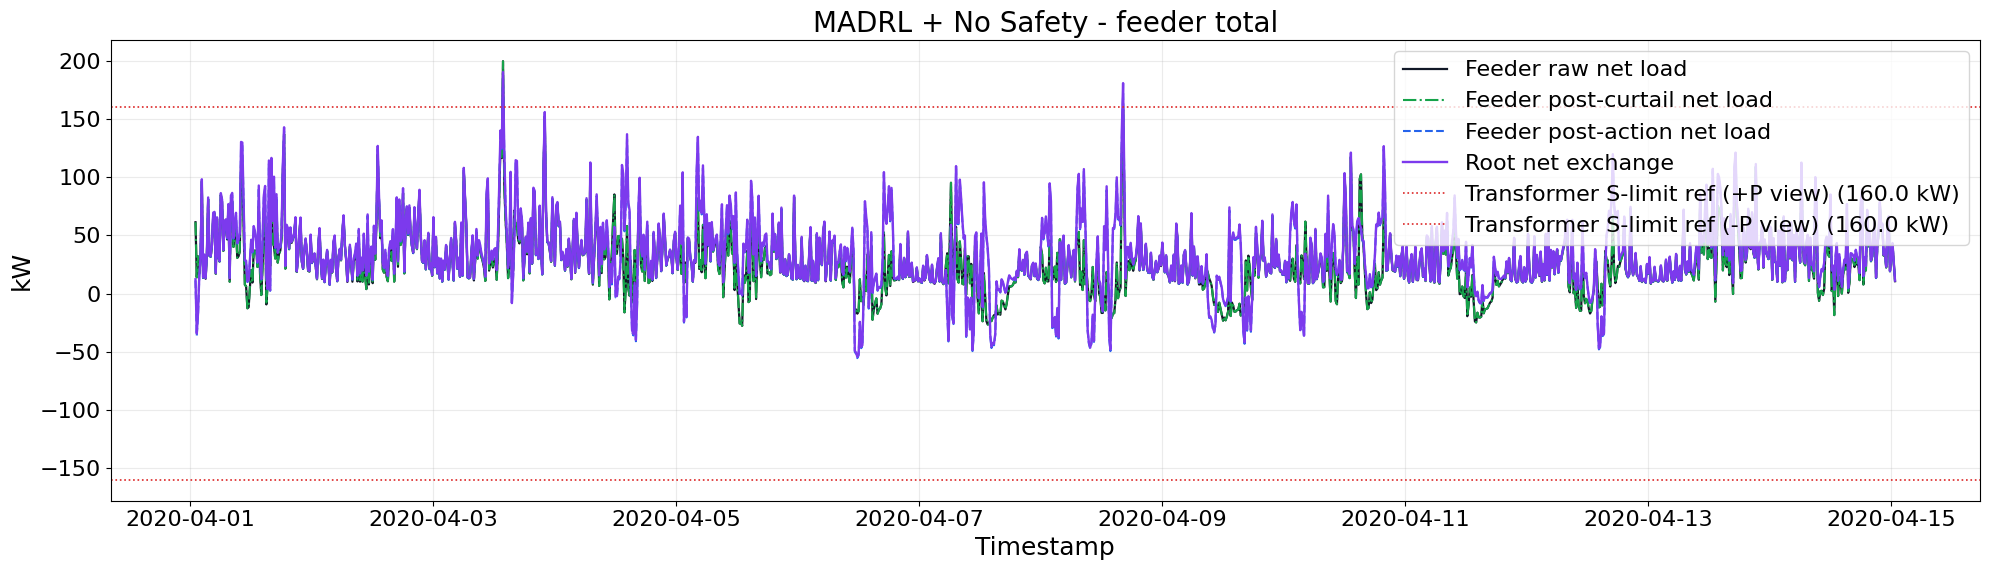

In [5]:

# 训练产物读取和重训都走共享 helper，避免三个 notebook 再各自维护 payload 和合同校验。
# 训练进度按 interaction step 推进，摘要指标每 progress_episode_interval 个 completed episodes 刷新一次。
resolved_training = resolve_madrl_notebook_training(
    cfg,
    spec=spec,
    force_retrain_madrl=bool(force_retrain_madrl),
    root=root,
    notebook_path='notebooks/madrl/train_base.ipynb',
)
train_result = dict(resolved_training['train_result'])
result_json_path = str(resolved_training['result_json_path'])
model_root = str(resolved_training['model_root'])
train_shared_data_signature = str(train_result.get('shared_data_signature') or '')

# 训练产物或复用产物都会在这里走同一条固定周评估链路，并把 compare-ready 记录写入 notebooks/record。
rollout = collect_madrl_rollout(
    cfg,
    model_root=model_root,
    algorithm=str(spec['algorithm']),
    experiment_name=str(spec['experiment_name']),
    label=str(spec['display_label']),
)
metrics_df = compare_rollout_metrics(rollout)
required_profit_columns = {
    'storage_charge_cost_total_eur',
    'storage_discharge_revenue_total_eur',
    'storage_profit_total_eur',
    'storage_objective_total_eur',
}
missing_profit_columns = required_profit_columns.difference(metrics_df.columns)
if missing_profit_columns:
    raise ValueError(
        f"train_base requires storage-profit metrics aligned with MISOCP. Missing: {sorted(missing_profit_columns)}. "
        "Rerun notebooks/madrl/train_base.ipynb after the max-storage-profit objective migration."
    )
if rollout.meta.get('objective_mode') != 'max_storage_profit':
    raise ValueError("train_base rollout meta must declare objective_mode='max_storage_profit'.")
record_manifest = save_rollout_record(
    rollout,
    category='madrl',
    scheme_name=str(spec['scheme_name']),
    root=root,
    config_snapshot={
        **config_snapshot,
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
    extra_meta={
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
)
display(metrics_df)
pprint({
    'model_root': model_root,
    'result_json_path': result_json_path,
    'shared_data_signature': train_result.get('shared_data_signature'),
    'record_dir': record_manifest['record_dir'],
    'episodes_completed': int(train_result.get('episodes_completed', 0)),
})

# 统一展示 MADRL 的关键图，和 MISOCP notebook 保持同一套验收视角。
_plot_specs = [
    ('1. 电力电量平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 总体储能充放功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(rollout)
    display(figure)
    plt.close(figure)


,episode,total_reward,madrl_r_inc,madrl_r_action_penalty,madrl_r_soc_regularization,madrl_r_throughput_bonus,madrl_r_safe_v,madrl_r_safe_line,madrl_r_safe_trafo,madrl_r_safe_total
290,291,-8.159022,-6.514154,-1.641615,-0.003246,0.0,0.0,0.0,0.0,0.0
291,292,-1.758983,-0.312832,-1.442502,-0.003653,0.0,0.0,0.0,0.0,0.0
292,293,20.146717,22.282310,-2.132210,-0.003485,0.0,0.0,0.0,0.0,0.0
293,294,42.742695,44.938717,-2.192376,-0.003482,0.0,0.0,0.0,0.0,0.0
294,295,-5.553823,-3.485708,-2.064595,-0.003543,0.0,0.0,0.0,0.0,0.0
295,296,0.747633,2.949095,-2.197927,-0.003554,0.0,0.0,0.0,0.0,0.0
296,297,1.792920,4.830758,-3.034442,-0.003453,0.0,0.0,0.0,0.0,0.0
297,298,-12.098759,-10.499931,-1.595252,-0.003600,0.0,0.0,0.0,0.0,0.0
298,299,-4.300282,-2.071816,-2.224720,-0.003712,0.0,0.0,0.0,0.0,0.0
299,300,-0.167505,1.524291,-1.687936,-0.003777,0.0,0.0,0.0,0.0,0.0


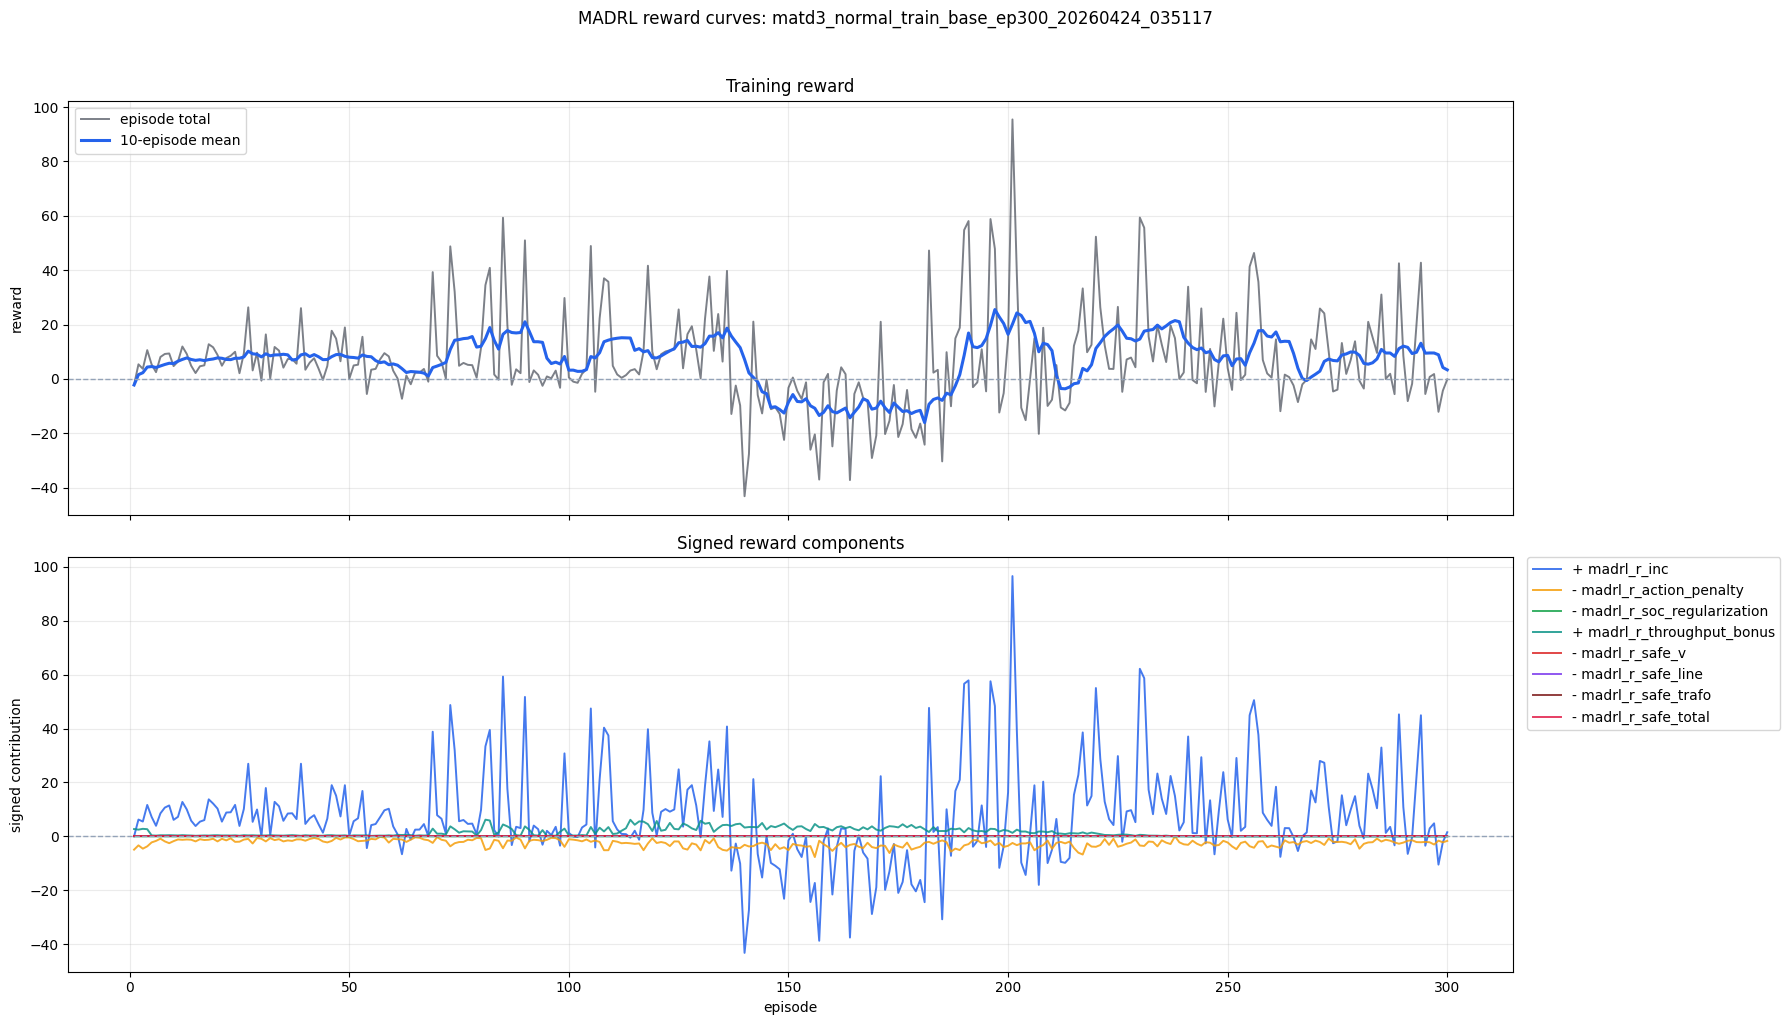

In [6]:
reward_summary_path = Path(
    train_result.get('reward_summary_path') or Path(result_json_path).with_name('train_reward_summary.json')
).resolve()
if not reward_summary_path.exists():
    raise FileNotFoundError(f"MADRL reward summary not found: {reward_summary_path}")

reward_summary = json.loads(reward_summary_path.read_text(encoding='utf-8'))
episodes = list(reward_summary.get('episodes') or [])
if not episodes:
    raise ValueError(f"MADRL reward summary '{reward_summary_path}' contains no episodes.")

reward_curve_df = pd.DataFrame({
    'episode': episodes,
    'total_reward': reward_summary.get('episode_total_reward', []),
})
if len(reward_curve_df['total_reward']) != len(episodes):
    raise ValueError("episode_total_reward length does not match episodes length.")

component_color_map = {
    'blue': '#2563eb',
    'amber': '#f59e0b',
    'green': '#16a34a',
    'teal': '#0d9488',
    'red': '#dc2626',
    'purple': '#7c3aed',
    'maroon': '#7f1d1d',
    'rose': '#e11d48',
    'slate': '#475569',
}
component_specs = []
for component_key, component_meta in dict(reward_summary.get('components') or {}).items():
    if component_key == 'madrl_r_total_internal':
        continue
    component_values = list(dict(component_meta).get('values') or [])
    if len(component_values) != len(episodes):
        raise ValueError(f"Reward component '{component_key}' length does not match episodes length.")
    reward_curve_df[component_key] = component_values
    component_specs.append((
        component_key,
        str(dict(component_meta).get('label') or component_key),
        component_color_map.get(str(dict(component_meta).get('color') or ''), '#6b7280'),
    ))

rolling_window = min(10, max(1, len(reward_curve_df)))
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

axes[0].plot(reward_curve_df['episode'], reward_curve_df['total_reward'], color='#111827', linewidth=1.4, alpha=0.55, label='episode total')
if rolling_window > 1:
    axes[0].plot(
        reward_curve_df['episode'],
        reward_curve_df['total_reward'].rolling(rolling_window, min_periods=1).mean(),
        color='#2563eb',
        linewidth=2.2,
        label=f'{rolling_window}-episode mean',
    )
axes[0].axhline(0.0, color='#94a3b8', linewidth=1.0, linestyle='--')
axes[0].set_title('Training reward')
axes[0].set_ylabel('reward')
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc='upper left')

for component_key, label, color in component_specs:
    axes[1].plot(reward_curve_df['episode'], reward_curve_df[component_key], linewidth=1.4, alpha=0.85, color=color, label=label)
axes[1].axhline(0.0, color='#94a3b8', linewidth=1.0, linestyle='--')
axes[1].set_title('Signed reward components')
axes[1].set_xlabel('episode')
axes[1].set_ylabel('signed contribution')
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0)

fig.suptitle(f"MADRL reward curves: {Path(model_root).name}", y=1.02)
fig.tight_layout()
display(reward_curve_df.tail(10))
display(fig)
plt.close(fig)
